In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# aesthetics
sns.set(style="whitegrid")
plt.rcParams.update({
    "font.size": 14,
    "font.weight": "bold",
    "axes.labelweight": "bold"
})

In [12]:
# Load your datasets
erg11_df = pd.read_csv("data/FLU_ERG11.tsv", sep="\t")
wt_df = pd.read_csv("data/FLU_WT.tsv", sep="\t")

# Add strain labels (optional)
erg11_df["Strain"] = "ERG11"
wt_df["Strain"] = "WT"

# Combine
df = pd.concat([erg11_df, wt_df], ignore_index=True)

# Preview
df.head()

,[FLU],Control,Ergosterol,Cholesterol,DMSO,Strain
0,10.000,0.139,0.149,0.144,0.143,ERG11
1,5.000,0.164,0.170,0.177,0.164,ERG11
2,2.500,0.162,0.470,0.194,0.233,ERG11
3,2.250,0.295,0.668,0.244,0.365,ERG11
4,1.125,0.691,0.702,0.695,0.670,ERG11


In [14]:
# Adjust column names if needed
treatment_cols = ["Control", "Ergosterol", "Cholesterol", "DMSO"]

df_long = df.melt(
    id_vars=["[FLU]", "Strain"],
    value_vars=treatment_cols,
    var_name="Treatment",
    value_name="OD"
)

df_long.head()

,[FLU],Strain,Treatment,OD
0,10.000,ERG11,Control,0.139
1,5.000,ERG11,Control,0.164
2,2.500,ERG11,Control,0.162
3,2.250,ERG11,Control,0.295
4,1.125,ERG11,Control,0.691


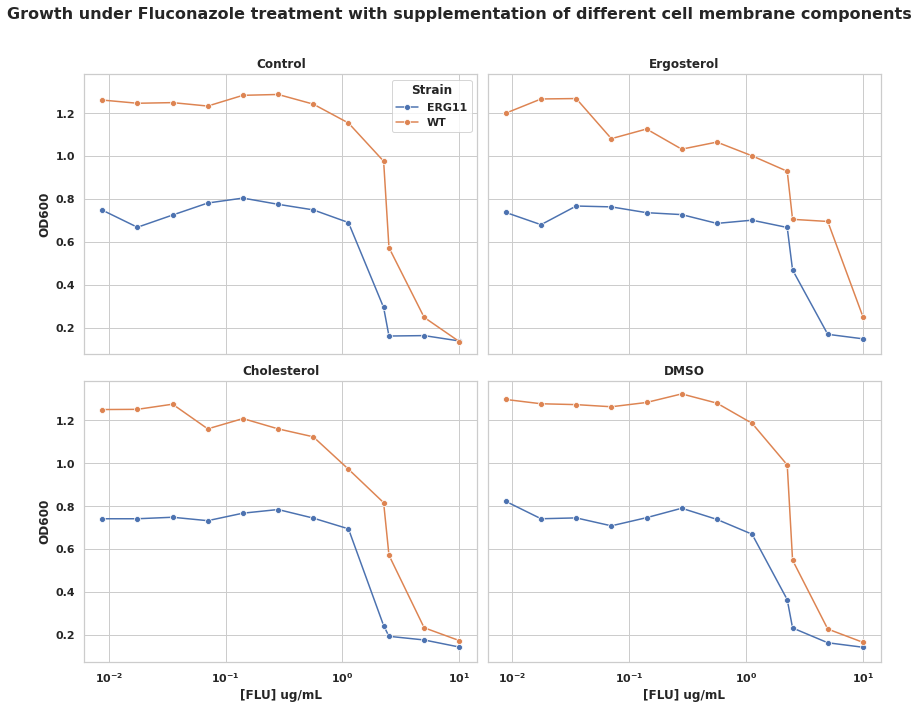

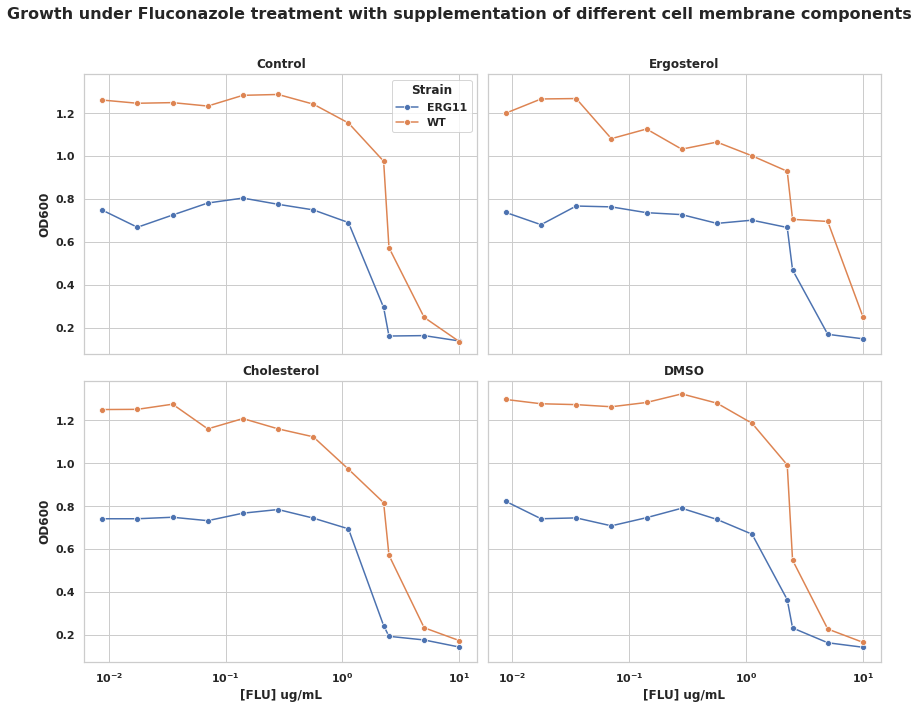

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)

treatments = ["Control", "Ergosterol", "Cholesterol", "DMSO"]

for i, treatment in enumerate(treatments):
    ax = axes[i // 2, i % 2]
    
    subset = df_long[df_long["Treatment"] == treatment]
    
    sns.lineplot(
        data=subset,
        x="[FLU]",
        y="OD",
        hue="Strain",      # WT vs ERG11
        marker="o",
        ax=ax
    )
    
    ax.set_xscale("log")
    ax.set_title(treatment, fontweight="bold")
    ax.set_xlabel("[FLU] ug/mL")
    ax.set_ylabel("OD600")

    # Clean legend (only once)
    if i == 0:
        ax.legend(title="Strain")
    else:
        ax.get_legend().remove()

plt.suptitle("Growth under Fluconazole treatment with supplementation of different cell membrane components", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# return fig explicitly (important for saving later)
fig

In [17]:
fig.savefig("plots/FLU_2x2_logplot.png", dpi=300, bbox_inches="tight")